In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv("CHDdata.csv")
data

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1
...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,0
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,1
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,0
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB


In [6]:
data.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [8]:
data.describe()

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,138.326840,3.635649,4.740325,25.406732,53.103896,26.044113,17.044394,42.816017,0.346320
std,20.496317,4.593024,2.070909,7.780699,9.817534,4.213680,24.481059,14.608956,0.476313
min,101.000000,0.000000,0.980000,6.740000,13.000000,14.700000,0.000000,15.000000,0.000000
25%,124.000000,0.052500,3.282500,19.775000,47.000000,22.985000,0.510000,31.000000,0.000000
50%,134.000000,2.000000,4.340000,26.115000,53.000000,25.805000,7.510000,45.000000,0.000000
75%,148.000000,5.500000,5.790000,31.227500,60.000000,28.497500,23.892500,55.000000,1.000000
max,218.000000,31.200000,15.330000,42.490000,78.000000,46.580000,147.190000,64.000000,1.000000


In [10]:
data.dtypes

,0
sbp,int64
tobacco,float64
ldl,float64
adiposity,float64
famhist,object
typea,int64
obesity,float64
alcohol,float64
age,int64
chd,int64


In [11]:
data.columns

Index(['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity',
       'alcohol', 'age', 'chd'],
      dtype='object')

In [12]:
data.isnull().sum()

,0
sbp,0
tobacco,0
ldl,0
adiposity,0
famhist,0
typea,0
obesity,0
alcohol,0
age,0
chd,0


In [13]:
data.dropna(inplace=True)
data.drop_duplicates()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1
...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,0
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,1
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,0
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,0


In [22]:
X=data[['age','obesity']]
X

,age,obesity
0,52,25.30
1,63,28.87
2,46,29.14
3,58,31.99
4,49,25.99
...,...,...
457,58,28.45
458,52,28.61
459,55,20.09
460,40,27.35


In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [29]:
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.3,
    min_samples=4
)

In [30]:
scan=dbscan.fit_predict(X)
data["Clusters"]=scan

In [31]:
data

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd,Clusters
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1,-1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1,-1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0,-1
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1,-1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1,-1
...,...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,0,-1
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,1,-1
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,0,-1
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,0,-1


In [35]:
data['Clusters'].unique()

array([-1,  5,  3,  6,  0,  1,  2,  4])

In [32]:
import matplotlib.pyplot as plt

/tmp/ipykernel_5011/922208176.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


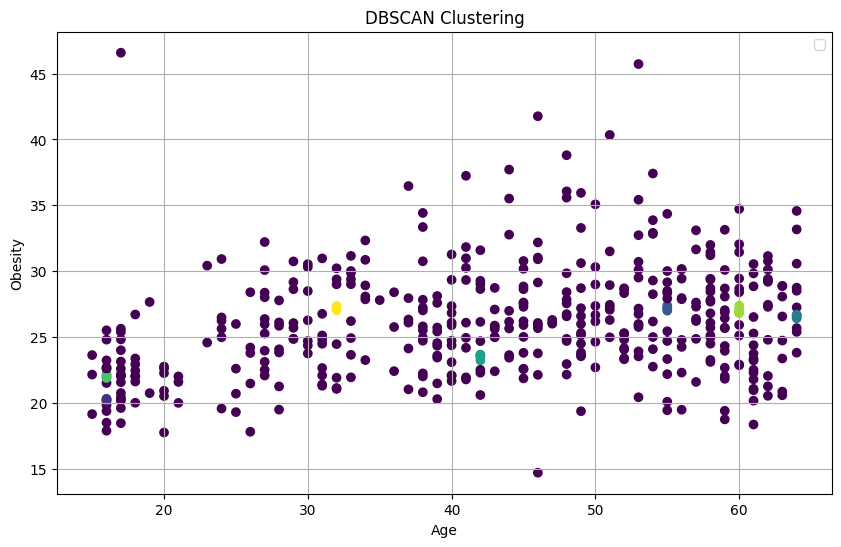

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(X['age'],X['obesity'],c=scan)

plt.xlabel("Age")
plt.ylabel("Obesity")

plt.title("DBSCAN Clustering")

plt.legend()
plt.grid(True)

plt.show()